In [1]:
# regular imports
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# for zip code distance
import requests
import math
from typing import Dict, List, Tuple, Optional

# Regression
from sklearn.linear_model import LogisticRegression

# FNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_class_weight

from google.colab import drive
drive.mount('/content/drive')

k ='/content/drive/MyDrive/IR/Title V Data Training/Projects/Will_Enroll_Data.xlsx'
df = pd.read_excel(k,sheet_name='data')
holdout = pd.read_excel(k,sheet_name='holdout')


df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5382 entries, 0 to 5381
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   FirstGen                550 non-null    object        
 1   SAT_S11                 853 non-null    float64       
 2   SAT_S12                 852 non-null    float64       
 3   Gender                  5382 non-null   object        
 4   Citizen                 5372 non-null   object        
 5   StudentType             5382 non-null   int64         
 6   MAJOR1                  5382 non-null   object        
 7   MAJOR2                  760 non-null    object        
 8   highschool_desc         5372 non-null   object        
 9   street                  5368 non-null   object        
 10  city                    5368 non-null  

In [2]:
holdout.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3258 entries, 0 to 3257
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Index                   3258 non-null   int64         
 1   Citizen                 3255 non-null   float64       
 2   MAJOR2                  1707 non-null   object        
 3   CITY                    2014 non-null   object        
 4   DEGREE1                 3258 non-null   object        
 5   FirstGen                248 non-null    object        
 6   ETHN                    2932 non-null   float64       
 7   NETHN                   5 non-null      float64       
 8   Gender                  3256 non-null   object        
 9   HighSchool_CLASS_RANK   1238 non-null   float64       
 10  highschool_desc         3153 non-null   object        
 11  HighSchool_GPA          1937 non-null   float64       
 12  HighSchool_PERCENTILE   1240 non-null   float64 

## **Data Preparation**
- Remove duplicates
- Check Anomolies:
 - outliers, and
 - data input errors
- Check missing values:
 - numerical: replace with 0
 - categoircal: replace with 'unknown'
- Data Prep requirement:
 - keep all FirstGen applicants
 - create balanced data among enrolled and not enrolled applicants
 - keep degree code, SAT_11 and 12, High School rank, percentile, GPA, the number of days from apply to admit
- Feature Engineer
  - create feature 'state' taking values of domestic, noncitizen, or unknown
  - create feature 'doublemajor'

In [3]:
import pandas as pd

def drop_duplicates(df):
    """
    Removes duplicate rows from the dataset.
    """
    return df.drop_duplicates()

def filter_by_column(df, column_name, value):
    """
    Filters rows in the dataframe based on a specific column value.
    """
    return df[df[column_name] == value]

def fill_missing_categorical(df, categorical_columns):
    """
    Fills missing values in categorical columns with 'unknown'.
    """
    for column in categorical_columns:
        df[column] = df[column].fillna('unknown')
    return df

def fill_missing_numeric(df, numeric_columns, fill_value=0):
    """
    Fills missing values in numeric columns with a specified value (default is 0).
    """
    for column in numeric_columns:
        df[column] = df[column].fillna(fill_value)
    return df

def create_state2_column(df):
    """
    Creates a new column 'state2' based on the 'Citizen' column.
    """
    df['state2'] = df.apply(
        lambda row: (
            'Domestic' if row['Citizen'] == 'Y' else
            'NonCitizen' if row['Citizen'] == 'N' else
            'Unknown' if pd.isna(row['Citizen']) else
            'Unknown'
        ),
        axis=1
    )
    return df

def drop_columns(df, columns_to_drop):
    """
    Drops specified columns from the dataframe.
    """
    return df.drop(columns=columns_to_drop, axis=1)
'''
def sample_data(df, n, random_state):
    """
    Randomly samples n rows from the dataframe.
    """
    return df.sample(n=n, random_state=random_state)

def shuffle_data(df, random_state):
    """
    Shuffles the rows of the dataframe and resets the index.
    """
    return df.sample(frac=1, random_state=random_state).reset_index(drop=True)
'''
def preprocess_data(df, categorical_columns, numeric_columns, columns_to_drop):
    """
    Applies all preprocessing steps to the dataset.
    """
    # Drop duplicates
    df_cleaned = drop_duplicates(df)

    # Fill missing values
    df_cleaned = fill_missing_categorical(df_cleaned, categorical_columns)
    df_cleaned = fill_missing_numeric(df_cleaned, numeric_columns)

    # Drop unnecessary columns
    df_cleaned = drop_columns(df_cleaned, columns_to_drop)

    return df_cleaned

def print_null_counts(df):
    """
    Prints the count of null values for each column in the dataframe.
    """
    null_counts = df.isnull().sum()
    print(null_counts)

def add_doublemajor_column(df, major2_col='MAJOR2', new_col='doublemajor'):
    """
    """
    df[new_col] = (~df[major2_col].isna() & (df[major2_col] != 'unknown')).astype(int)
    return df

def map_degree_to_numeric_str(df, degree_col='degree1', new_col='admit_deg_code'):

    # Define the mapping rules
    degree_mapping = {
        "None": 1,
        "Pre-Professional":3,
        "BS":5,
        "BA":6,
        "AS":20,
        "BMus":43,
        "MBA":49,
        "MAT":50,
        "BSW":76,
        "BFA":103
    }

    # Apply the mapping to create the new column
    df[new_col] = df[degree_col].map(degree_mapping).astype(str).fillna("unknown")

    return df
def add_label(df):
  df['Enrolled2'] = None
  return df

In [4]:
unknown_count = (holdout['MAJOR2'].isna()).sum()
print(f"Count of 'unknown' in MAJOR2: {unknown_count}")

Count of 'unknown' in MAJOR2: 1551


In [5]:
## Holdout data preperation

# Define column lists
numeric_columns = [
    'SAT_S11', 'SAT_S12', 'HighSchool_GPA',
    'HighSchool_PERCENTILE', 'HighSchool_CLASS_RANK', 'NumDays_app_adm','doublemajor'
]

categorical_columns = [
    'FirstGen', 'Gender', 'StudentType',
    'highschool_desc', 'NETHN', 'admit_deg_code', 'Index','MAJOR1','MAJOR2'
]

columns_to_drop = [
    'CITY', 'STREET','STATE', 'Application Ineligible', 'Application Entered',
    'Admitted',  'Application Withdrawn', 'Admission Withdrawn',
    'Denied', 'rank','Citizen'
]

# Create 'doublemajor' column before preprocessing
holdout = add_doublemajor_column(holdout ,  major2_col='MAJOR2', new_col='doublemajor')
holdout = add_label(holdout)
# Apply preprocessing to the holdout dataset
holdout_cleaned = preprocess_data(holdout, categorical_columns, numeric_columns, columns_to_drop)
#holdout_cleaned = add_doublemajor_column(holdout_cleaned ,  major2_col='MAJOR2', new_col='doublemajor')

holdout_cleaned = map_degree_to_numeric_str(holdout_cleaned, degree_col='DEGREE1', new_col='admit_deg_code')
print_null_counts(holdout_cleaned)

Index                       0
MAJOR2                      0
DEGREE1                     0
FirstGen                    0
ETHN                      326
NETHN                       0
Gender                      0
HighSchool_CLASS_RANK       0
highschool_desc             0
HighSchool_GPA              0
HighSchool_PERCENTILE       0
MAJOR1                      0
RACE                      842
RELIGION                  632
ZIP                      1264
SAT_S11                     0
SAT_S12                     0
StudentType                 0
admit_deg_code              0
NumDays_app_adm             0
will_enroll_202602       3258
doublemajor                 0
Enrolled2                3258
dtype: int64


In [6]:
holdout_cleaned.head()

,Index,MAJOR2,DEGREE1,FirstGen,ETHN,NETHN,Gender,HighSchool_CLASS_RANK,highschool_desc,HighSchool_GPA,...,RELIGION,ZIP,SAT_S11,SAT_S12,StudentType,admit_deg_code,NumDays_app_adm,will_enroll_202602,doublemajor,Enrolled2
0,944162,Cognitive/Behavioral Neurosci,BS,unknown,1.0,unknown,F,0.0,Public HS-CA,0.0,...,Christian,92551,0.0,0.0,9,5.0,0.0,NaN,1,None
1,967839,unknown,BS,unknown,1.0,unknown,M,0.0,Non-SDA International HS,0.0,...,Baptist,NaN,0.0,0.0,5,5.0,0.0,NaN,0,None
2,971393,Pre-Medicine,BA,unknown,2.0,unknown,F,494.0,Public HS-CA,0.0,...,No affliation/none listed,92337-7605,0.0,0.0,9,6.0,0.0,NaN,1,None
3,975117,Communication:Public Relations,BS,FIRSTGEN,2.0,unknown,M,182.0,Public HS-CA,2.9,...,Christian,92505-3030,530.0,470.0,5,5.0,56.0,NaN,1,None
4,981460,Business: Business & Society,BS,unknown,1.0,unknown,M,6.0,SDA HS-PU Conf Constituent,0.0,...,Seventh-day Adventist,92026-1100,670.0,610.0,9,5.0,39.0,NaN,1,None


In [7]:
holdout_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3258 entries, 0 to 3257
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Index                  3258 non-null   int64  
 1   MAJOR2                 3258 non-null   object 
 2   DEGREE1                3258 non-null   object 
 3   FirstGen               3258 non-null   object 
 4   ETHN                   2932 non-null   float64
 5   NETHN                  3258 non-null   object 
 6   Gender                 3258 non-null   object 
 7   HighSchool_CLASS_RANK  3258 non-null   float64
 8   highschool_desc        3258 non-null   object 
 9   HighSchool_GPA         3258 non-null   float64
 10  HighSchool_PERCENTILE  3258 non-null   float64
 11  MAJOR1                 3258 non-null   object 
 12  RACE                   2416 non-null   object 
 13  RELIGION               2626 non-null   object 
 14  ZIP                    1994 non-null   object 
 15  SAT_

In [8]:
holdout_cleaned['doublemajor'].value_counts()

,count
doublemajor,
1,1707
0,1551


### select the features for the model prediction

In [9]:
def preprocess_final_model(df, numerical_features, categorical_features):
    # Step 4: Filter the dataset to include only the required features
    required_features = numerical_features + categorical_features
    df = df[required_features]

    return df

In [10]:
# Define the features used in the final model
numerical_features = [
    'SAT_S11', 'SAT_S12', 'HighSchool_GPA',
    'HighSchool_PERCENTILE', 'HighSchool_CLASS_RANK', 'NumDays_app_adm','doublemajor'
]

categorical_features = [
    'FirstGen', 'Gender', 'StudentType','Index',
    'highschool_desc', 'NETHN', 'admit_deg_code', 'Enrolled2'
]

# Preprocess the holdout dataset
df_holdout = preprocess_final_model(holdout_cleaned, numerical_features, categorical_features)
df_holdout.head()

,SAT_S11,SAT_S12,HighSchool_GPA,HighSchool_PERCENTILE,HighSchool_CLASS_RANK,NumDays_app_adm,doublemajor,FirstGen,Gender,StudentType,Index,highschool_desc,NETHN,admit_deg_code,Enrolled2
0,0.0,0.0,0.0,0.0,0.0,0.0,1,unknown,F,9,944162,Public HS-CA,unknown,5.0,None
1,0.0,0.0,0.0,0.0,0.0,0.0,0,unknown,M,5,967839,Non-SDA International HS,unknown,5.0,None
2,0.0,0.0,0.0,18.0,494.0,0.0,1,unknown,F,9,971393,Public HS-CA,unknown,6.0,None
3,530.0,470.0,2.9,56.0,182.0,56.0,1,FIRSTGEN,M,5,975117,Public HS-CA,unknown,5.0,None
4,670.0,610.0,0.0,77.0,6.0,39.0,1,unknown,M,9,981460,SDA HS-PU Conf Constituent,unknown,5.0,None


In [11]:
df_holdout.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3258 entries, 0 to 3257
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SAT_S11                3258 non-null   float64
 1   SAT_S12                3258 non-null   float64
 2   HighSchool_GPA         3258 non-null   float64
 3   HighSchool_PERCENTILE  3258 non-null   float64
 4   HighSchool_CLASS_RANK  3258 non-null   float64
 5   NumDays_app_adm        3258 non-null   float64
 6   doublemajor            3258 non-null   int64  
 7   FirstGen               3258 non-null   object 
 8   Gender                 3258 non-null   object 
 9   StudentType            3258 non-null   int64  
 10  Index                  3258 non-null   int64  
 11  highschool_desc        3258 non-null   object 
 12  NETHN                  3258 non-null   object 
 13  admit_deg_code         3258 non-null   object 
 14  Enrolled2              0 non-null      object 
dtypes: f

In [12]:
df_holdout['doublemajor'].value_counts()

,count
doublemajor,
1,1707
0,1551


### feature comparison between two sets

In [13]:
df_cleaned = df.drop_duplicates()
df_cleaned.shape

df_filtered = df_cleaned[df_cleaned['Enrolled2']==1]
df_filtered2= df_cleaned[df_cleaned['Enrolled2']==0]
##df_filtered.info()
d = df_filtered2[df_filtered2['FirstGen'].notnull()]
d.shape
df_filtered.shape

df_sampled1 = df_filtered2.sample(n=1308, random_state=618)
df_sample = pd.concat([df_sampled1, df_filtered])
df_shuffled = df_sample.sample(frac=1, random_state=1152).reset_index(drop=True)
df_drop = df_shuffled.copy().drop(['street', 'city', 'Application Ineligible','Application Entered', 'Admitted', 'Enrolled', 'enrolled_fall_2024', 'enrolled_fall_2023',
       'enrolled_fall_2022', 'enrolled_fall_2021'], axis=1)
categorical_columns = [
    'FirstGen', 'Gender', 'Citizen', 'StudentType', 'MAJOR1', 'MAJOR2',
    'highschool_desc', 'state', 'zip', 'RELIGION', 'NETHN', 'RACE','admit_deg_code'
]
df_drop[categorical_columns] = df_drop[categorical_columns].fillna('unknown')
df_drop.info()

numeric_columns = [
    'SAT_S11', 'SAT_S12','HighSchool_GPA', 'HighSchool_PERCENTILE',
    'HighSchool_CLASS_RANK', 'NumDays_app_adm',
]
for column in numeric_columns:
    df_drop[column] = df_drop[column].fillna(0)  # Replace NaNs with 0
'''
df_drop['state2'] = df_drop.apply(
    lambda row: (
        'Domestic' if row['Citizen'] == 'Y' else
        'NonCitizen' if row['Citizen'] == 'N' else
        'Unknown' if pd.isna(row['Citizen']) else
        'Unknown'
    ),
    axis=1
)
'''
null_counts = df_drop.isnull().sum()
print(null_counts)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2616 entries, 0 to 2615
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FirstGen               2616 non-null   object 
 1   SAT_S11                444 non-null    float64
 2   SAT_S12                444 non-null    float64
 3   Gender                 2616 non-null   object 
 4   Citizen                2616 non-null   object 
 5   StudentType            2616 non-null   int64  
 6   MAJOR1                 2616 non-null   object 
 7   MAJOR2                 2616 non-null   object 
 8   highschool_desc        2616 non-null   object 
 9   state                  2616 non-null   object 
 10  zip                    2616 non-null   object 
 11  RELIGION               2616 non-null   object 
 12  NETHN                  2616 non-null   object 
 13  RACE                   2616 non-null   object 
 14  HighSchool_GPA         2401 non-null   float64
 15  High

In [14]:
def compare_features(df1, df_holdout):
    """
    Compares the columns (features) between two dataframes and identifies:
    - Common columns
    - Columns unique to each dataframe

    Parameters:
    - df1 (pd.DataFrame): The first dataframe.
    - df_holdout (pd.DataFrame): The holdout dataframe.

    Returns:
    - None (prints the comparison summary).
    """
    # Get the sets of columns from both dataframes
    df1_columns = set(df1.columns)
    holdout_columns = set(df_holdout.columns)

    # Find common columns
    common_columns = df1_columns.intersection(holdout_columns)

    # Find columns unique to each dataframe
    df1_only_columns = df1_columns.difference(holdout_columns)
    holdout_only_columns = holdout_columns.difference(df1_columns)

    # Print the results
    print("Comparison of Features Between `df1` and `df_holdout`:")
    print("---------------------------------------------------")
    print(f"Number of columns in `df1`: {len(df1_columns)}")
    print(f"Number of columns in `df_holdout`: {len(holdout_columns)}")
    print(f"Number of common columns: {len(common_columns)}")
    print(f"Columns in `df1` but not in `df_holdout`: {df1_only_columns}")
    print(f"Columns in `df_holdout` but not in `df1`: {holdout_only_columns}")

In [15]:
data = df_drop.copy()
data.dropna(inplace=True)
data.describe()

,SAT_S11,SAT_S12,StudentType,HighSchool_GPA,HighSchool_PERCENTILE,HighSchool_CLASS_RANK,NumDays_app_adm,Enrolled2
count,2616.000000,2616.000000,2616.000000,2616.000000,2616.000000,2616.000000,2616.000000,2616.000000
mean,89.686544,87.178899,5.649847,3.233471,38.692278,77.680046,47.737003,0.500000
std,202.166793,197.362901,1.475778,1.085198,35.784106,125.207598,54.766764,0.500096
min,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,-184.000000,0.000000
25%,0.000000,0.000000,5.000000,3.030000,0.000000,0.000000,16.000000,0.000000
50%,0.000000,0.000000,5.000000,3.510000,41.000000,15.000000,32.000000,0.500000
75%,0.000000,0.000000,5.000000,3.880000,72.000000,112.000000,57.000000,1.000000
max,790.000000,800.000000,9.000000,4.900000,100.000000,1013.000000,509.000000,1.000000


In [16]:
data.describe(include='object')

,FirstGen,Gender,Citizen,MAJOR1,MAJOR2,highschool_desc,state,zip,RELIGION,NETHN,RACE,admit_deg_code
count,2616,2616,2616,2616,2616,2616,2616,2616,2616,2616,2616,2616.0
unique,2,3,2,96,65,13,52,2227,34,8,21,12.0
top,unknown,F,Y,Criminal Justice,unknown,Public HS-CA,CA,unknown,Seventh-day Adventist,unknown,W,5.0
freq,2339,1620,2271,460,2238,1356,1956,35,1017,2552,1284,1349.0


In [17]:
if 'admit_deg_code' in df_drop.columns:
    # Convert the column to string and replace NaN and 0 with "unknown"
    data['admit_deg_code'] = (
        data['admit_deg_code']
        .replace(0, 'unknown')  # Replace 0 with "unknown"
        .fillna('unknown')     # Replace NaN with "unknown"
        .astype(str)           # Ensure the column is of string type
    )
else:
    print("'admit_deg_code' column does not exist in the DataFrame.")

admit_deg_code_counts =data['admit_deg_code'].value_counts(dropna=False)
print("Unique values and their counts in 'admit_deg_code':")
print(admit_deg_code_counts)


Unique values and their counts in 'admit_deg_code':
admit_deg_code
5.0        1349
3.0         558
6.0         390
unknown     175
103.0        68
76.0         42
43.0         13
20.0          9
49.0          6
1.0           3
50.0          3
Name: count, dtype: int64


In [18]:
data['doublemajor'] = ((data['MAJOR1'].notnull()) & (data['MAJOR2'] !='unknown')).astype(int)

data.drop(['zip','state','RACE','MAJOR2','MAJOR1','RELIGION','Citizen'], axis=1, inplace=True)

In [19]:
data.describe(include = 'all')

,FirstGen,SAT_S11,SAT_S12,Gender,StudentType,highschool_desc,NETHN,HighSchool_GPA,HighSchool_PERCENTILE,HighSchool_CLASS_RANK,NumDays_app_adm,admit_deg_code,Enrolled2,doublemajor
count,2616,2616.000000,2616.000000,2616,2616.000000,2616,2616,2616.000000,2616.000000,2616.000000,2616.000000,2616,2616.000000,2616.000000
unique,2,NaN,NaN,3,NaN,13,8,NaN,NaN,NaN,NaN,11,NaN,NaN
top,unknown,NaN,NaN,F,NaN,Public HS-CA,unknown,NaN,NaN,NaN,NaN,5.0,NaN,NaN
freq,2339,NaN,NaN,1620,NaN,1356,2552,NaN,NaN,NaN,NaN,1349,NaN,NaN
mean,NaN,89.686544,87.178899,NaN,5.649847,NaN,NaN,3.233471,38.692278,77.680046,47.737003,NaN,0.500000,0.144495
std,NaN,202.166793,197.362901,NaN,1.475778,NaN,NaN,1.085198,35.784106,125.207598,54.766764,NaN,0.500096,0.351659
min,NaN,0.000000,0.000000,NaN,5.000000,NaN,NaN,0.000000,0.000000,0.000000,-184.000000,NaN,0.000000,0.000000
25%,NaN,0.000000,0.000000,NaN,5.000000,NaN,NaN,3.030000,0.000000,0.000000,16.000000,NaN,0.000000,0.000000
50%,NaN,0.000000,0.000000,NaN,5.000000,NaN,NaN,3.510000,41.000000,15.000000,32.000000,NaN,0.500000,0.000000
75%,NaN,0.000000,0.000000,NaN,5.000000,NaN,NaN,3.880000,72.000000,112.000000,57.000000,NaN,1.000000,0.000000


In [20]:
nan_mask = data.isnull()
print("Mask of NaN values:")
true_indices = data.stack()[data.stack() == True]
print("Indices of True values:")
print(true_indices)

df1= data.copy()
df1 = df1.replace(True, np.nan)

Mask of NaN values:
Indices of True values:
0     Enrolled2      1
2     Enrolled2      1
      doublemajor    1
3     Enrolled2      1
4     Enrolled2      1
                    ..
2612  Enrolled2      1
      doublemajor    1
2613  Enrolled2      1
2614  Enrolled2      1
2615  Enrolled2      1
Length: 1785, dtype: object


In [21]:
df1 = data.copy()

max_gpa = df1['HighSchool_GPA'].max()

# Replace the maximum value with its value divided by 100
df1['HighSchool_GPA'] = df1['HighSchool_GPA'].apply(lambda x: x / 100 if x == max_gpa else x)
df1['NumDays_app_adm'] = df1['NumDays_app_adm'].apply(lambda x: 0 if x < 0 else x)

In [22]:
df1.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FirstGen,2616,2,unknown,2339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SAT_S11,2616.0,NaN,NaN,NaN,89.686544,202.166793,0.0,0.0,0.0,0.0,790.0
SAT_S12,2616.0,NaN,NaN,NaN,87.178899,197.362901,0.0,0.0,0.0,0.0,800.0
Gender,2616,3,F,1620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StudentType,2616.0,NaN,NaN,NaN,5.649847,1.475778,5.0,5.0,5.0,5.0,9.0
highschool_desc,2616,13,Public HS-CA,1356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NETHN,2616,8,unknown,2552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HighSchool_GPA,2616.0,NaN,NaN,NaN,3.231617,1.086493,0.0,3.03,3.51,3.88,4.84
HighSchool_PERCENTILE,2616.0,NaN,NaN,NaN,38.692278,35.784106,0.0,0.0,41.0,72.0,100.0
HighSchool_CLASS_RANK,2616.0,NaN,NaN,NaN,77.680046,125.207598,0.0,0.0,15.0,112.0,1013.0


In [23]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
SAT_S11,2616.0,89.686544,202.166793,0.0,0.00,0.00,0.00,790.00
SAT_S12,2616.0,87.178899,197.362901,0.0,0.00,0.00,0.00,800.00
StudentType,2616.0,5.649847,1.475778,5.0,5.00,5.00,5.00,9.00
HighSchool_GPA,2616.0,3.231617,1.086493,0.0,3.03,3.51,3.88,4.84
HighSchool_PERCENTILE,2616.0,38.692278,35.784106,0.0,0.00,41.00,72.00,100.00
HighSchool_CLASS_RANK,2616.0,77.680046,125.207598,0.0,0.00,15.00,112.00,1013.00
NumDays_app_adm,2616.0,47.831422,54.558743,0.0,16.00,32.00,57.00,509.00
Enrolled2,2616.0,0.500000,0.500096,0.0,0.00,0.50,1.00,1.00
doublemajor,2616.0,0.144495,0.351659,0.0,0.00,0.00,0.00,1.00


In [24]:
df1.describe(include = ['object', 'category']).T

,count,unique,top,freq
FirstGen,2616,2,unknown,2339
Gender,2616,3,F,1620
highschool_desc,2616,13,Public HS-CA,1356
NETHN,2616,8,unknown,2552
admit_deg_code,2616,11,5.0,1349


In [25]:
df1.dropna(inplace=True)
df1.shape

(2616, 14)

In [26]:
df1.columns

Index(['FirstGen', 'SAT_S11', 'SAT_S12', 'Gender', 'StudentType',
       'highschool_desc', 'NETHN', 'HighSchool_GPA', 'HighSchool_PERCENTILE',
       'HighSchool_CLASS_RANK', 'NumDays_app_adm', 'admit_deg_code',
       'Enrolled2', 'doublemajor'],
      dtype='object')

### compare the features in the two tables

In [27]:
compare_features(df1, df_holdout)

Comparison of Features Between `df1` and `df_holdout`:
---------------------------------------------------
Number of columns in `df1`: 14
Number of columns in `df_holdout`: 15
Number of common columns: 14
Columns in `df1` but not in `df_holdout`: set()
Columns in `df_holdout` but not in `df1`: {'Index'}


# Data Checkpoint

In [38]:
savepath = '/content/drive/MyDrive/IR/Title V Data Training/Projects'
filename = 'train_Val_Test_EnrollmentPredictions202602.csv'

# Combine the directory path and filename
full_path = f"{savepath}/{filename}"

# Save the DataFrame to the specified path
df1.to_csv(full_path, index=False)

# EDA

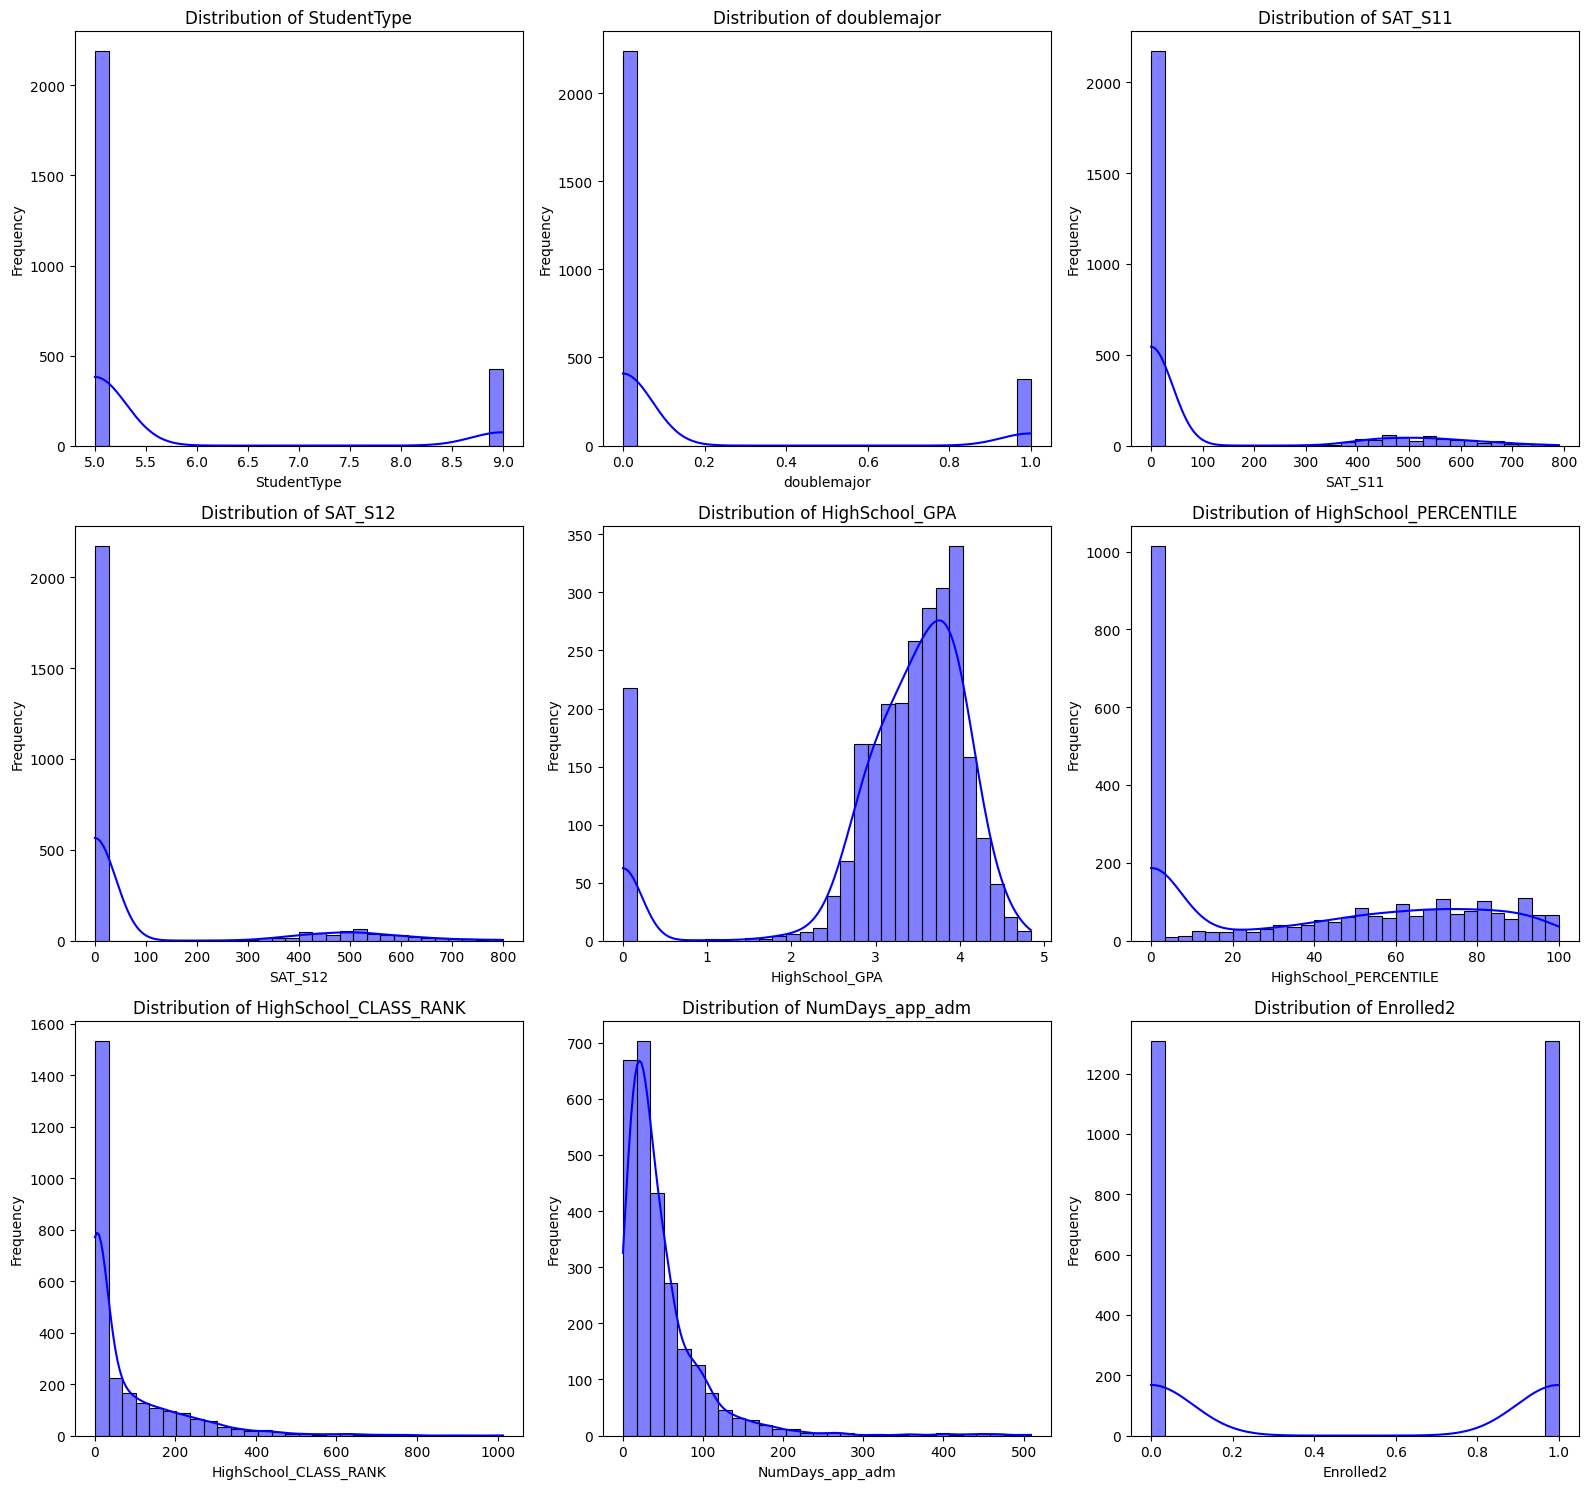

<ipython-input-28-70cea4d4689f>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='viridis', order=df[feature].value_counts().index, ax=axes[i])
<ipython-input-28-70cea4d4689f>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='viridis', order=df[feature].value_counts().index, ax=axes[i])
<ipython-input-28-70cea4d4689f>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='viridis', order=df[feature].value_counts().index, ax=axes[i])
<ipython-input-28-70ce

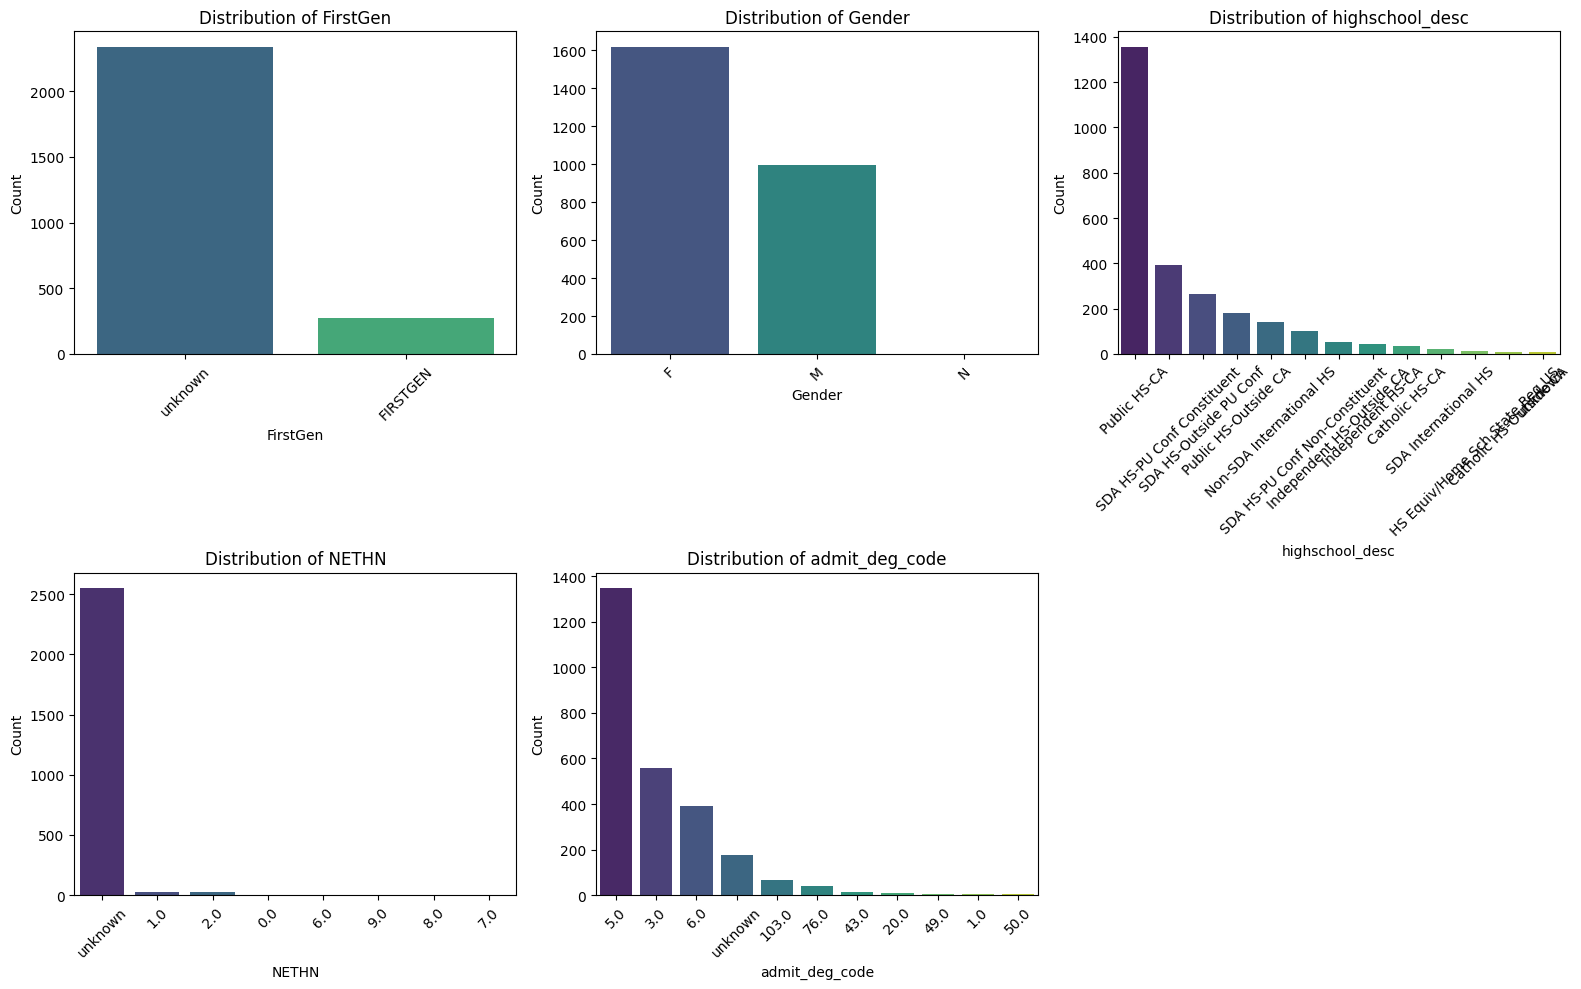

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
features = ['FirstGen', 'Gender', 'StudentType',
            'highschool_desc', 'NETHN', 'admit_deg_code','doublemajor',

            'SAT_S11', 'SAT_S12', 'HighSchool_GPA',
            'HighSchool_PERCENTILE', 'HighSchool_CLASS_RANK', 'NumDays_app_adm',
              'Enrolled2']
# Separate numerical and categorical features
numerical_features = df1[features].select_dtypes(include='number').columns.tolist()
categorical_features = df1[features].select_dtypes(exclude='number').columns.tolist()


# Define number of rows and columns for subplots
def plot_numerical_features(df, numerical_features, nrows, ncols):
    """
    Plot distributions for numerical features in an n x m grid.

    Args:
    - df: DataFrame containing the features.
    - numerical_features: List of numerical feature names.
    - nrows: Number of rows in the subplot grid.
    - ncols: Number of columns in the subplot grid.
    """
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))  # Adjust size
    axes = axes.flatten()  # Flatten axes for easy iteration

    for i, feature in enumerate(numerical_features):
        sns.histplot(df[feature], kde=True, bins=30, color='blue', ax=axes[i])
        axes[i].set_title(f'Distribution of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')

    # Remove empty subplots if numerical_features < nrows * ncols
    for j in range(len(numerical_features), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


def plot_categorical_features(df, categorical_features, nrows, ncols):
    """
    Plot counts for categorical features in an n x m grid.

    Args:
    - df: DataFrame containing the features.
    - categorical_features: List of categorical feature names.
    - nrows: Number of rows in the subplot grid.
    - ncols: Number of columns in the subplot grid.
    """
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))  # Adjust size
    axes = axes.flatten()  # Flatten axes for easy iteration

    for i, feature in enumerate(categorical_features):
        sns.countplot(data=df, x=feature, palette='viridis', order=df[feature].value_counts().index, ax=axes[i])
        axes[i].set_title(f'Distribution of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Remove empty subplots if categorical_features < nrows * ncols
    for j in range(len(categorical_features), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# Determine grid shape (nrows, ncols)
numerical_nrows = math.ceil(len(numerical_features) / 3)
numerical_ncols = 3  # 3 columns per row
categorical_nrows = math.ceil(len(categorical_features) / 3)
categorical_ncols = 3  # 3 columns per row

# Plot numerical features
plot_numerical_features(df1, numerical_features, numerical_nrows, numerical_ncols)

# Plot categorical features
plot_categorical_features(df1, categorical_features, categorical_nrows, categorical_ncols)

### One-hot Encoding
### Normaliztion
### Scaling


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix


X=df1.drop(columns = 'Enrolled2')
y=df1['Enrolled2']

# Separate numerical and categorical features based on X (not df1)
#numerical_features = X.select_dtypes(include='number').columns.tolist()
#categorical_features = X.select_dtypes(exclude='number').columns.tolist()
numerical_features = [ 'SAT_S11', 'SAT_S12', 'HighSchool_GPA',
            'HighSchool_PERCENTILE', 'HighSchool_CLASS_RANK', 'NumDays_app_adm',
             ]
categorical_features = ['FirstGen', 'Gender', 'StudentType',
            'highschool_desc', 'NETHN', 'admit_deg_code','doublemajor'
            ]

# Transformer for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # Fill missing values
    ('convert_to_string', FunctionTransformer(lambda x: x.astype(str))),    # Ensure all values are strings
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))        # One-hot encode
])

# Transformer for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Fill missing values with mean
    ('scaler', StandardScaler())                 # Standardize numerical features
])

# Preprocessor combining numerical and categorical transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),  # Apply numerical transformer
        ('cat', categorical_transformer, categorical_features)  # Apply categorical transformer
    ]
)

# Complete pipeline with preprocessing and logistic regression
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=500))  # Logistic regression with increased iterations
])

# Split data into train and test sets
from sklearn.model_selection import train_test_split
# Initial split: 60% train, 40% (temporary set for validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=380
)

# Secondary split: 50% of the temporary set for validation, 50% for test
# Since the temporary set is 40% of the data, this results in 20% for validation and 20% for test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=380
)
# Print shapes to confirm the split
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)


# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

train_accuracy = pipeline.score(X_train, y_train)
val_accuracy = pipeline.score(X_val, y_val)
test_accuracy = pipeline.score(X_test, y_test)
print(f"Training Accuracy: {train_accuracy}")
print('*****'*10)
print(f"Validation Accuracy: {val_accuracy}")
print('*****'*10)
print(f"Test Accuracy: {test_accuracy}")
print('*****'*10)


#-------------------------------------------------------

# Get predictions
y_pred = pipeline.predict(X_test)

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision}")

# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall}")

# F1 Score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{conf_matrix}")

Training set: (1569, 13) (1569,)
Validation set: (523, 13) (523,)
Test set: (524, 13) (524,)
Training Accuracy: 0.715742511153601
**************************************************
Validation Accuracy: 0.6615678776290631
**************************************************
Test Accuracy: 0.666030534351145
**************************************************
Precision: 0.7671957671957672
Recall: 0.5253623188405797
F1 Score: 0.6236559139784946
Confusion Matrix:
[[204  44]
 [131 145]]


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### parameter optimization for a higher recall score

In [30]:
import numpy as np
from sklearn.metrics import classification_report
# Get predicted probabilities
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Set a custom threshold (e.g., 0.3 instead of 0.5)
threshold = 0.35
y_pred_custom = (y_prob >= threshold).astype(int)

# Generate the classification report
report = classification_report(y_test, y_pred_custom,target_names=['Class 0', 'Class 1'])
print(report)

              precision    recall  f1-score   support

     Class 0       0.71      0.43      0.54       248
     Class 1       0.62      0.84      0.71       276

    accuracy                           0.65       524
   macro avg       0.67      0.64      0.63       524
weighted avg       0.66      0.65      0.63       524



In [31]:
# Feature Importance Section

# Extract the logistic regression model
log_reg = pipeline.named_steps['classifier']

# Get the feature names from the preprocessor
numeric_feature_names = numerical_features
categorical_feature_names = pipeline.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(categorical_features)

# Combine all feature names
all_feature_names = np.concatenate([numeric_feature_names, categorical_feature_names])

# Get the coefficients from the logistic regression model
coefficients = log_reg.coef_.flatten()

# Create a DataFrame to display feature importance
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})

# Sort by absolute value of coefficients
feature_importance_df['Absolute_Coefficient'] = feature_importance_df['Coefficient'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Absolute_Coefficient', ascending=False)

# Display the top features
print("\nFeature Importance (Top 10):")
feature_importance_df.head(10)


Feature Importance (Top 10):


,Feature,Coefficient,Absolute_Coefficient
18,highschool_desc_SDA HS-PU Conf Constituent,2.469222,2.469222
9,StudentType_9,2.012239,2.012239
19,highschool_desc_SDA HS-PU Conf Non-Constituent,1.479902,1.479902
29,admit_deg_code_20.0,-1.340836,1.340836
11,highschool_desc_HS Equiv/Home Sch State Req US,1.240771,1.240771
10,highschool_desc_Catholic HS-Outside CA,-1.137490,1.137490
13,highschool_desc_Independent HS-Outside CA,-0.976827,0.976827
14,highschool_desc_Non-SDA International HS,-0.896792,0.896792
16,highschool_desc_Public HS-Outside CA,-0.725887,0.725887
21,highschool_desc_unknown,-0.596600,0.596600


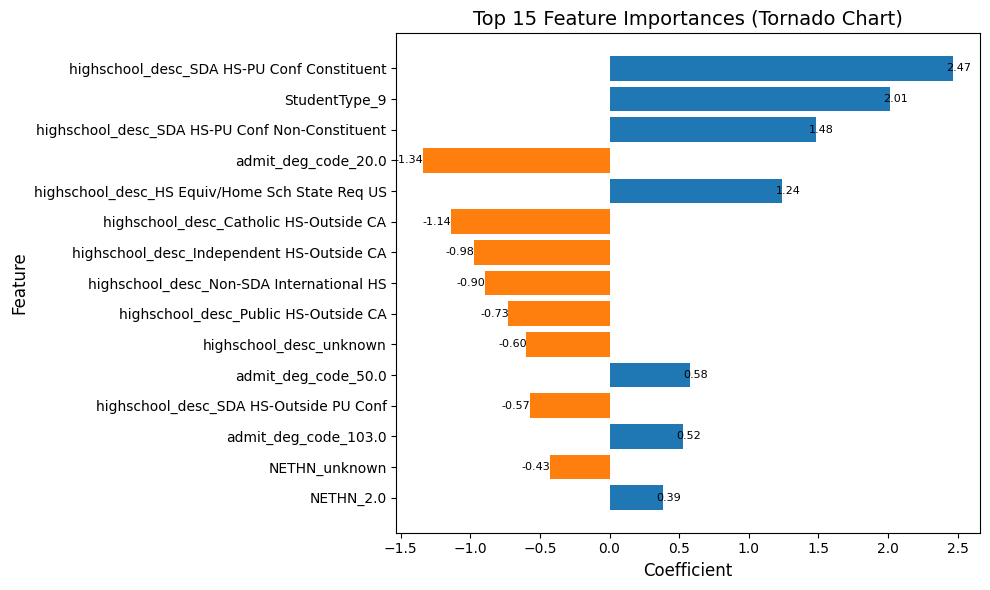

In [32]:
import matplotlib.pyplot as plt

# Select top 15 most important features
top_features = feature_importance_df.head(15)

# Extract feature names and coefficients
features = top_features['Feature']
coefficients = top_features['Coefficient']

# Plot the tornado chart
plt.figure(figsize=(10, 6))
bars = plt.barh(features, coefficients, color=['#1f77b4' if coef > 0 else '#ff7f0e' for coef in coefficients])

# Add labels and title
plt.xlabel('Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Feature Importances (Tornado Chart)', fontsize=14)

# Add values to the bars
for bar in bars:
    plt.text(
        bar.get_width() + 0.04 if bar.get_width() > 0 else bar.get_width() - 0.10,  # Position for positive/negative
        bar.get_y() + bar.get_height() / 2,  # Vertically center the text
        f'{bar.get_width():.2f}',  # Format the coefficient to 2 decimals
        va='center',
        ha='center',
        fontsize=8
    )

# Reverse the order of features so the largest is on top
plt.gca().invert_yaxis()

# Display the chart
plt.tight_layout()
plt.show()

#Observations (Poe)
### Key Observations
1. Strong Recruitment, Weak Conversion:
The university's ability to attract applicants shows that its promotional efforts are effective. However, the inability to convert these applicants into enrolled students suggests a need for improvements in the admissions experience, financial aid offerings, or perceived value of the programs.
2. Competition with Community Colleges:
Community colleges are likely the largest competitor for associate degree students. These institutions excel at affordability, flexibility, and career-focused programs, making them attractive to students seeking two-year degrees.
3. Strategic Positioning:
The university needs to differentiate its associate degree programs by emphasizing unique benefits, such as:
 - Affordable Education Close to Home: Highlight the university's location and affordability, making it an accessible option for local students.
 - Pathways to Careers and Beyond: Focus on career-oriented programs that lead to job opportunities in teh local community.
 - Seamless transition to the university’s bachelor’s degree programs.
 - We're Here for You and Your Family: Appeal to Hispanic cultureal values of family and community by emphasizing support systems, such as mentoring, family-inclusive events, and personalized advising.
4. Student Decision-Making Process:
Understanding why students choose other schools is critical. Factors such as cost, location, transfer opportunities, or program flexibility may heavily influence decisions. Gathering feedback through surveys or exit interviews with declined applicants can provide valuable insights.

### **Strategic Positioning (poe)**

1. **Emphasize Inclusivity and Shared Values**:
   - While the university is SDA-affiliated, it can focus on **shared values** that appeal to everyone, including Catholics, such as:
     - A commitment to **family, community, and service**—values that resonate strongly with Hispanic culture, regardless of specific religious affiliation.
     - The idea of **character-building, education, and moral values**, which are also important in Catholic education.
   - Avoid overly emphasizing the SDA identity in promotional materials for associate degree programs. Instead, highlight the university as a **welcoming, diverse, and service-oriented institution**.

2. **Focus on Neutral, Career-Oriented Messaging**:
   - Shift the messaging for the associate degree programs to focus on **career preparation, affordability, and accessibility**, rather than religion. For example:
     - "Start your journey to a high-paying career with an affordable, locally-based associate degree."
     - "Flexible programs designed for your busy life—online, evening, and weekend options available."
   - This way, the programs appeal to practical needs and career goals rather than religious identity.

3. **Build Trust Through Community Engagement**:
   - Overcome resistance by demonstrating the university’s commitment to serving the **entire community**, including Catholics. For example:
     - Partner with **local Catholic churches** to provide workshops, scholarships, or community events. While Catholics may not naturally prefer the university, showing a willingness to serve the broader community can build goodwill and trust.
     - Host **family-friendly events** or open houses that emphasize the university’s role as an inclusive educational institution, not just an SDA-affiliated school.

4. **Highlight Student Success Stories**:
   - Feature testimonials and success stories from **Hispanic students**, especially those who are Catholic or from other non-SDA backgrounds. These stories can help break down stereotypes and show that the university is a good fit for students of all faiths.

5. **Promote Neutral and Practical Benefits**:
   - Focus on **benefits that transcend religious differences**, such as:
     - Small class sizes and personalized attention.
     - Affordable tuition and generous financial aid.
     - Strong job placement rates and partnerships with local employers.
   - These practical benefits are likely to resonate with Catholic families who may prioritize affordability, quality education, and career outcomes over religious alignment.

6. **Offer Scholarships and Financial Incentives**:
   - Create **scholarships for local Hispanic students**, regardless of religious affiliation. Name the scholarships neutrally (e.g., "Hispanic Community Leadership Scholarship") to emphasize inclusivity.
   - Reduce financial barriers by promoting affordability and offering competitive financial aid packages, which are likely to appeal to Catholic families.

7. **Partner with Catholic-Friendly Organizations**:
   - Partner with local Hispanic organizations, businesses, or civic groups rather than exclusively SDA-affiliated groups. This helps position the university as a community-focused institution rather than one catering to a specific faith.

8. **Focus on Health and Wellness Programs**:
   - If the university offers health-related associate degrees (e.g., nursing, medical assisting), emphasize its strengths in these fields. SDA institutions typically emphasize health and wellness, which can resonate with Catholic families looking for practical, career-oriented programs.


### **Key Messaging**
The university should position its associate degree programs with messaging that appeals to Hispanic Catholic families while minimizing any barriers associated with its SDA affiliation. For example:

- **Primary Messages**:
  - "An affordable education with small class sizes and personalized support—right here in your community."
  - "Flexible programs designed for your busy life—online, evening, and weekend options available."
  - "Start your journey to a rewarding career in healthcare, business, or education."

- **Secondary Messages**:
  - "We welcome students from all backgrounds and faiths. Your success is our mission."
  - "Join a supportive, close-knit campus community where you’ll get the attention you deserve."

---

### **Addressing Religious Concerns**
To overcome religious objections, the university should focus on:
- **De-emphasizing religious affiliation** in communications about associate degree programs. Instead, focus on practical benefits like affordability, flexibility, and career preparation.
- **Positioning the university as a community partner** that serves all faiths and backgrounds, not just SDA students.
- **Creating a welcoming environment** for Catholic students by:
  - Offering non-denominational campus events and activities.
  - Providing spaces for students of all faiths to practice their religion comfortably.



### **Summary**
To attract Hispanic students, many of whom may be Catholic and hesitant about attending an SDA-affiliated university, the university should:
1. Focus on **inclusive messaging** that emphasizes shared values and practical benefits, rather than religious identity.
2. Build trust with the local Hispanic community through **scholarships, partnerships, and outreach efforts**.
3. Highlight the university’s **affordability, flexibility, and career-focused programs**, as these factors are likely to appeal to Catholic families.

By positioning itself as a welcoming, community-centered institution, the university can better compete for Hispanic students—Catholic or otherwise—and increase enrollment in its associate degree programs.


In [33]:
def predict_enrollment(trained_model, holdout_df, feature_columns, index_column='Index'):
    """
    Use a trained model to predict the `Enrolled2` column in the holdout dataset,
    ensuring the index column is preserved and reattached after predictions.

    Parameters:
    - trained_model: The trained machine learning model.
    - holdout_df (pd.DataFrame): The holdout dataset.
    - feature_columns (list): List of feature columns to use for prediction.
    - index_column (str): The name of the column that serves as the index.

    Returns:
    - pd.DataFrame: The holdout dataset with the predicted `Enrolled2` column.
    """
    # Step 1: Save the index column and drop it temporarily
    index_values = holdout_df[index_column]
    holdout_df = holdout_df.drop(columns=[index_column])

    # Step 2: Perform predictions using the trained model
    predictions = trained_model.predict(holdout_df[feature_columns])

    # Step 3: Assign predictions to the `Enrolled2` column
    holdout_df['Enrolled2'] = predictions

    # Step 4: Add the index column back to the DataFrame
    holdout_df[index_column] = index_values

    # Step 5: Reorder columns to place the index column first if desired
    holdout_df = holdout_df[[index_column] + [col for col in holdout_df.columns if col != index_column]]

    return holdout_df

In [34]:
def predict_enrollment(trained_model, holdout_df, index_column='Index', target_column='Enrolled2'):
    """
    Use a trained model to predict the `Enrolled2` column in the holdout dataset,
    ensuring the index column is preserved and reattached after predictions.

    Parameters:
    - trained_model: The trained machine learning model.
    - holdout_df (pd.DataFrame): The holdout dataset.
    - index_column (str): The name of the column serving as the index.
    - target_column (str): The name of the column to predict (e.g., 'Enrolled2').

    Returns:
    - pd.DataFrame: The holdout dataset with the predicted target column.
    """
    # Step 1: Save the index column and drop it temporarily
    index_values = holdout_df[index_column]
    holdout_df = holdout_df.drop(columns=[index_column])

    # Step 2: Dynamically determine feature columns (exclude target column)
    feature_columns = [col for col in holdout_df.columns if col != target_column]

    # Step 3: Perform predictions using the trained model
    predictions = trained_model.predict(holdout_df[feature_columns])

    # Step 4: Assign predictions to the target column (e.g., 'Enrolled2')
    holdout_df[target_column] = predictions

    # Step 5: Add the index column back to the DataFrame
    holdout_df[index_column] = index_values

    # Step 6: Reorder columns to place the index column first if desired
    holdout_df = holdout_df[[index_column] + [col for col in holdout_df.columns if col != index_column]]

    return holdout_df

In [35]:
def predict_enrollment_with_threshold(pipeline, holdout_df, threshold=0.35, index_column='Index', target_column='Enrolled2'):
    """
    Use a trained pipeline to predict the target column in the holdout dataset using a custom threshold.

    Parameters:
    - pipeline: The trained machine learning pipeline.
    - holdout_df (pd.DataFrame): The holdout dataset.
    - threshold (float): The custom threshold to classify probabilities into binary predictions.
    - index_column (str): The name of the column serving as the index.
    - target_column (str): The name of the column to predict (e.g., 'Enrolled2').

    Returns:
    - pd.DataFrame: The holdout dataset with the predicted target column.
    """
    # Step 1: Save the index column and drop it temporarily
    index_values = holdout_df[index_column]
    holdout_df = holdout_df.drop(columns=[index_column])

    # Step 2: Dynamically determine feature columns (exclude target column)
    feature_columns = [col for col in holdout_df.columns if col != target_column]

    # Step 3: Predict probabilities for the positive class (Class 1)
    y_prob = pipeline.predict_proba(holdout_df[feature_columns])[:, 1]

    # Step 4: Apply the custom threshold to generate binary predictions
    y_pred_custom = (y_prob >= threshold).astype(int)

    # Step 5: Assign predictions to the target column (e.g., 'Enrolled2')
    holdout_df[target_column] = y_pred_custom

    # Step 6: Add the index column back to the DataFrame
    holdout_df[index_column] = index_values

    # Step 7: Reorder columns to place the index column first if desired
    holdout_df = holdout_df[[index_column] + [col for col in holdout_df.columns if col != index_column]]

    return holdout_df

In [36]:
# Apply the trained pipeline to predict `Enrolled2` with a custom threshold
df_holdout = predict_enrollment_with_threshold(
    pipeline=pipeline,
    holdout_df=df_holdout,
    threshold=0.35,
    index_column='Index',
    target_column='Enrolled2'
)

# Display the updated holdout dataset
df_holdout

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Index,SAT_S11,SAT_S12,HighSchool_GPA,HighSchool_PERCENTILE,HighSchool_CLASS_RANK,NumDays_app_adm,doublemajor,FirstGen,Gender,StudentType,highschool_desc,NETHN,admit_deg_code,Enrolled2
0,944162,0.0,0.0,0.0,0.0,0.0,0.0,1,unknown,F,9,Public HS-CA,unknown,5.0,1
1,967839,0.0,0.0,0.0,0.0,0.0,0.0,0,unknown,M,5,Non-SDA International HS,unknown,5.0,0
2,971393,0.0,0.0,0.0,18.0,494.0,0.0,1,unknown,F,9,Public HS-CA,unknown,6.0,1
3,975117,530.0,470.0,2.9,56.0,182.0,56.0,1,FIRSTGEN,M,5,Public HS-CA,unknown,5.0,1
4,981460,670.0,610.0,0.0,77.0,6.0,39.0,1,unknown,M,9,SDA HS-PU Conf Constituent,unknown,5.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3253,1035740,0.0,0.0,0.0,0.0,0.0,0.0,1,unknown,M,5,unknown,unknown,6.0,0
3254,1035743,0.0,0.0,0.0,0.0,0.0,0.0,0,unknown,F,5,Public HS-CA,unknown,5.0,0
3255,1035744,0.0,0.0,0.0,0.0,0.0,0.0,1,unknown,F,5,unknown,unknown,6.0,0
3256,1035745,0.0,0.0,0.0,0.0,0.0,0.0,1,FIRSTGEN,F,5,unknown,unknown,5.0,0


In [37]:
savepath = '/content/drive/MyDrive/IR/Title V Data Training/Projects'
filename = 'EnrollmentPredictions202602.csv'

# Combine the directory path and filename
full_path = f"{savepath}/{filename}"

# Save the DataFrame to the specified path
df_holdout.to_csv(full_path, index=False)